Leyendo.
Se cargó el archivo dataset1.txt con (3250, 4) filas y columnas.
Se cargó el archivo dataset2.txt con (5000, 2) filas y columnas.
Se cargó el archivo dataset3.txt con (5000, 2) filas y columnas.
Se cargó el archivo dataset4.txt con (5000, 2) filas y columnas.

Ingresar el número de columnas a extraer: 4

Valores fitrados mayores a 50.0 o negativos:
[]


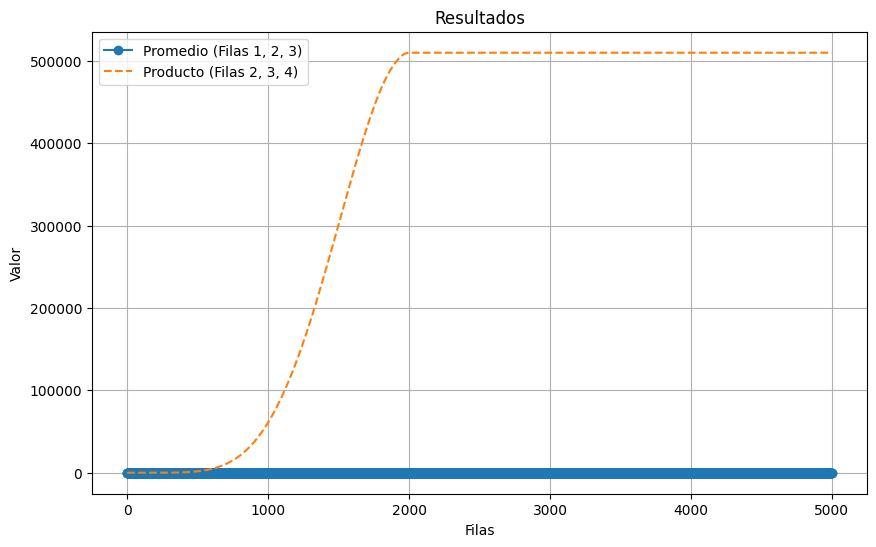

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Leer archivos con ciclo for
file_list = ['dataset1.txt', 'dataset2.txt', 'dataset3.txt', 'dataset4.txt']
raw_data_storage = []

print("Leyendo.")
for file_name in file_list:
    # Leer los datos con NP
    data = np.loadtxt(file_name)
    raw_data_storage.append(data)
    # shape devuelve indices y elementos correspondientes
    print(f"Se cargó el archivo {file_name} con {data.shape} filas y columnas.")

# Número de columnas a extraer mayor a dos
try:
    num_cols_to_extract = int(input("\nIngresar el número de columnas a extraer: "))
    if num_cols_to_extract < 2:
      # raise utiliza el error en try/except
        raise ValueError
except ValueError:
    num_cols_to_extract = 2
    print("Minimo 2 columnas.")

# Ajustar las dimensiones con zero padding.
# Determinar el número máxico de filas.
max_rows = 0
for data_set in raw_data_storage:
    if len(data_set) > max_rows:
        max_rows = len(data_set)

# Almacenar columnas extras necesarias
processed_columns = []

# Procesar y equilibrar cada conjunto de datos
for data_set in raw_data_storage:
    # Columnas necesarias
    extracted = data_set[:, :num_cols_to_extract]

    # Ceros a añadir
    padding_size = max_rows - len(extracted)

    # Añadir ceros usando np.pad
    padded = np.pad(extracted, ((0, padding_size), (0, 0)), mode='constant', constant_values=0)
    processed_columns.append(padded)

# Promedio
# Formula: (c1 + c2 + c3) / 3
col_index = 0
avg_result = (processed_columns[0][:, col_index] +
              processed_columns[1][:, col_index] +
              processed_columns[2][:, col_index]) / 3

# Producto elemento por elemento de 3 archivos diferentes
prod_result = (processed_columns[1][:, 0] * processed_columns[2][:, 0] * processed_columns[3][:, 0])


# Extraer valores en función de un umbral y de los signos negativos
threshold = 50.0
filtered_data = []

sample_column = processed_columns[0][:, 0]
for value in sample_column:
    if value > threshold:
        filtered_data.append(value)
    elif value < 0:
        filtered_data.append(value)

print(f"\nValores fitrados mayores a {threshold} o negativos:")
print(filtered_data)

# Gráficas
plt.figure(figsize=(10, 6))
plt.plot(avg_result, label='Promedio (Filas 1, 2, 3)', marker='o')
plt.plot(prod_result, label='Producto (Filas 2, 3, 4)', linestyle='--')
plt.title('Resultados')
plt.xlabel('Filas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()